In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import scipy.sparse as sp
import joblib

# Load the raw dataset
df = pd.read_csv('../../data/raw/Fraudtrain.csv')

# Convert trans_date_trans_time to pandas datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Extract the transaction hour, month, and day of the week
df['trans_hour'] = df['trans_date_trans_time'].dt.hour
df['trans_month'] = df['trans_date_trans_time'].dt.month 
df['trans_dayofweek'] = df['trans_date_trans_time'].dt.day_name()

# Convert unix_time to datetime and calculate timedelta_last_trans
df['transaction_time'] = pd.to_datetime(df['unix_time'], unit='s')
df = df.sort_values(by=['cc_num', 'transaction_time'])
df['unix_time_prev_trans'] = df.groupby(by=['cc_num'])['unix_time'].shift(1)
df = df.assign(unix_time_prev_trans=df['unix_time_prev_trans'].fillna(df['unix_time'] - 86400))
df['timedelta_last_trans'] = (df['unix_time'] - df['unix_time_prev_trans']) // 60

# Calculate customer age at the time of transaction
df['dob'] = pd.to_datetime(df['dob'])
df['cust_age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

# Drop unnecessary columns
drop_cols = [
    'Unnamed: 0', 'street', 'zip', 'first', 'last', 'trans_num', 'trans_date_trans_time',
    'transaction_time', 'unix_time', 'unix_time_prev_trans', 'lat', 'long',
    'merch_lat', 'merch_long', 'dob'
]
df = df.drop(columns=drop_cols)

# Split the data into X and y
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

# Split the data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)

# One-Hot Encoding for all categorical features
ohe = OneHotEncoder(sparse_output=True, drop='first', handle_unknown='ignore')

# Identify categorical columns for encoding
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

# Fit and transform the training data using sparse matrices
X_train_encoded_sparse = ohe.fit_transform(X_train[categorical_cols])

# Transform the validation data using sparse matrices
X_val_encoded_sparse = ohe.transform(X_val[categorical_cols])

# Concatenate encoded columns with the original data (excluding original categorical columns)
X_train_sparse = sp.hstack((X_train.drop(columns=categorical_cols).values, X_train_encoded_sparse))
X_val_sparse = sp.hstack((X_val.drop(columns=categorical_cols).values, X_val_encoded_sparse))

# Save the OneHotEncoder for later use with the unseen data
joblib.dump(ohe, 'onehot_encoder.joblib')

# Display the shapes of the processed data
print("Training Data Shape:", X_train_sparse.shape)
print("Validation Data Shape:", X_val_sparse.shape)


Training Data Shape: (907672, 2155)
Validation Data Shape: (389003, 2155)


In [6]:
# Load the unseen dataset
df_unseen = pd.read_csv('../../data/raw/Fraudtest.csv')

# Apply the same preprocessing steps as done on the train and validation data

# Convert trans_date_trans_time to pandas datetime
df_unseen['trans_date_trans_time'] = pd.to_datetime(df_unseen['trans_date_trans_time'])

# Extract the transaction hour, month, and day of the week
df_unseen['trans_hour'] = df_unseen['trans_date_trans_time'].dt.hour
df_unseen['trans_month'] = df_unseen['trans_date_trans_time'].dt.month 
df_unseen['trans_dayofweek'] = df_unseen['trans_date_trans_time'].dt.day_name()

# Convert unix_time to datetime and calculate timedelta_last_trans
df_unseen['transaction_time'] = pd.to_datetime(df_unseen['unix_time'], unit='s')
df_unseen = df_unseen.sort_values(by=['cc_num', 'transaction_time'])
df_unseen['unix_time_prev_trans'] = df_unseen.groupby(by=['cc_num'])['unix_time'].shift(1)
df_unseen = df_unseen.assign(unix_time_prev_trans=df_unseen['unix_time_prev_trans'].fillna(df_unseen['unix_time'] - 86400))
df_unseen['timedelta_last_trans'] = (df_unseen['unix_time'] - df_unseen['unix_time_prev_trans']) // 60

# Calculate customer age at the time of transaction
df_unseen['dob'] = pd.to_datetime(df_unseen['dob'])
df_unseen['cust_age'] = (df_unseen['trans_date_trans_time'] - df_unseen['dob']).dt.days // 365

# Drop unnecessary columns
df_unseen = df_unseen.drop(columns=drop_cols)

# Separate features from target
X_unseen = df_unseen.drop(columns=["is_fraud"])
y_unseen = df_unseen["is_fraud"]

# Load the previously saved OneHotEncoder
ohe = joblib.load('onehot_encoder.joblib')

# Transform the unseen data using sparse matrices
X_unseen_encoded_sparse = ohe.transform(X_unseen[categorical_cols])

# Concatenate encoded columns with the original data (excluding original categorical columns)
X_unseen_sparse = sp.hstack((X_unseen.drop(columns=categorical_cols).values, X_unseen_encoded_sparse))

# Display the shape of the processed unseen data
print("\nUnseen Data Shape:", X_unseen_sparse.shape)


C:\Users\Black\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [3, 5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(



Unseen Data Shape: (555719, 2155)


In [7]:
from xgboost import XGBClassifier
from sklearn.feature_selection import RFE

# Initialize the XGBoost model
xgb_model = XGBClassifier(random_state=42)

# Number of features to select
n_features_to_select = 50

# Initialize RFE with the XGBoost model
rfe = RFE(estimator=xgb_model, n_features_to_select=n_features_to_select, step=1)

# Fit RFE on the sparse training data
rfe.fit(X_train_sparse, y_train)

# Transform the training, validation, and unseen datasets
X_train_rfe = rfe.transform(X_train_sparse)
X_val_rfe = rfe.transform(X_val_sparse)
X_unseen_rfe = rfe.transform(X_unseen_sparse)

# Display the shapes of the selected features
print("Selected Features for Training Data Shape:", X_train_rfe.shape)
print("Selected Features for Validation Data Shape:", X_val_rfe.shape)
print("Selected Features for Unseen Data Shape:", X_unseen_rfe.shape)


Selected Features for Training Data Shape: (907672, 50)
Selected Features for Validation Data Shape: (389003, 50)
Selected Features for Unseen Data Shape: (555719, 50)


In [8]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc, classification_report, confusion_matrix

# Initialize the XGBoost model
xgb_model = XGBClassifier(random_state=42)

# Train the model on the RFE-selected features of the training data
xgb_model.fit(X_train_rfe, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [9]:
# Make predictions on the validation data
y_val_pred = xgb_model.predict(X_val_rfe)
y_val_pred_proba = xgb_model.predict_proba(X_val_rfe)[:, 1]

# Evaluate the model's performance on the validation data
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_pred_proba)
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_val_pred_proba)
pr_auc = auc(recall_vals, precision_vals)

# Confusion matrix
conf_matrix = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = conf_matrix.ravel()

print("Validation Data Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"PR AUC: {pr_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))
print("\nConfusion Matrix:")
print(conf_matrix)
print(f"True Positives (TP): {tp}")
print(f"False Positives (FP): {fp}")
print(f"True Negatives (TN): {tn}")
print(f"False Negatives (FN): {fn}")


Validation Data Evaluation:
Accuracy: 0.9989
Precision: 0.9629
Recall: 0.8415
F1 Score: 0.8981
ROC AUC: 0.9992
PR AUC: 0.9540

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    386751
           1       0.96      0.84      0.90      2252

    accuracy                           1.00    389003
   macro avg       0.98      0.92      0.95    389003
weighted avg       1.00      1.00      1.00    389003


Confusion Matrix:
[[386678     73]
 [   357   1895]]
True Positives (TP): 1895
False Positives (FP): 73
True Negatives (TN): 386678
False Negatives (FN): 357


In [10]:
# Make predictions on the unseen data
y_unseen_pred = xgb_model.predict(X_unseen_rfe)
y_unseen_pred_proba = xgb_model.predict_proba(X_unseen_rfe)[:, 1]

# Evaluate the model's performance on the unseen data
accuracy_unseen = accuracy_score(y_unseen, y_unseen_pred)
precision_unseen = precision_score(y_unseen, y_unseen_pred)
recall_unseen = recall_score(y_unseen, y_unseen_pred)
f1_unseen = f1_score(y_unseen, y_unseen_pred)
roc_auc_unseen = roc_auc_score(y_unseen, y_unseen_pred_proba)
precision_vals_unseen, recall_vals_unseen, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc_unseen = auc(recall_vals_unseen, precision_vals_unseen)

# Confusion matrix for unseen data
conf_matrix_unseen = confusion_matrix(y_unseen, y_unseen_pred)
tn_unseen, fp_unseen, fn_unseen, tp_unseen = conf_matrix_unseen.ravel()

print("\nUnseen Data Evaluation:")
print(f"Accuracy: {accuracy_unseen:.4f}")
print(f"Precision: {precision_unseen:.4f}")
print(f"Recall: {recall_unseen:.4f}")
print(f"F1 Score: {f1_unseen:.4f}")
print(f"ROC AUC: {roc_auc_unseen:.4f}")
print(f"PR AUC: {pr_auc_unseen:.4f}")
print("\nClassification Report:")
print(classification_report(y_unseen, y_unseen_pred))
print("\nConfusion Matrix:")
print(conf_matrix_unseen)
print(f"True Positives (TP): {tp_unseen}")
print(f"False Positives (FP): {fp_unseen}")
print(f"True Negatives (TN): {tn_unseen}")
print(f"False Negatives (FN): {fn_unseen}")



Unseen Data Evaluation:
Accuracy: 0.9989
Precision: 0.9258
Recall: 0.7683
F1 Score: 0.8397
ROC AUC: 0.9975
PR AUC: 0.8998

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.93      0.77      0.84      2145

    accuracy                           1.00    555719
   macro avg       0.96      0.88      0.92    555719
weighted avg       1.00      1.00      1.00    555719


Confusion Matrix:
[[553442    132]
 [   497   1648]]
True Positives (TP): 1648
False Positives (FP): 132
True Negatives (TN): 553442
False Negatives (FN): 497


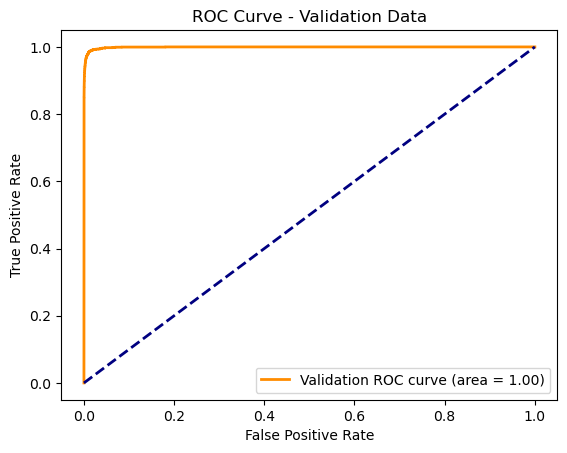

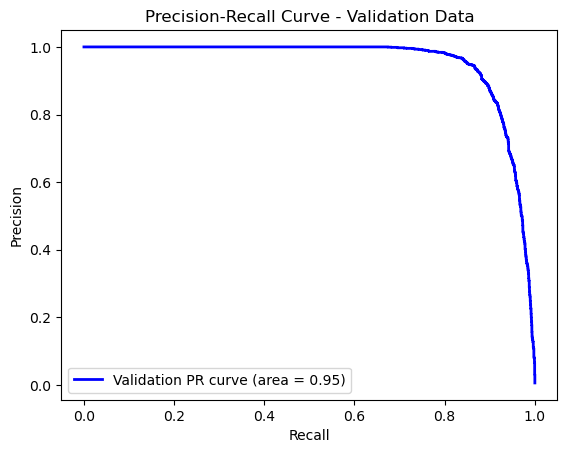

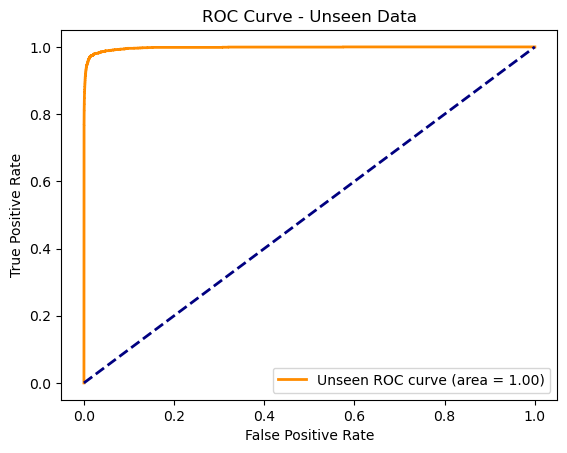

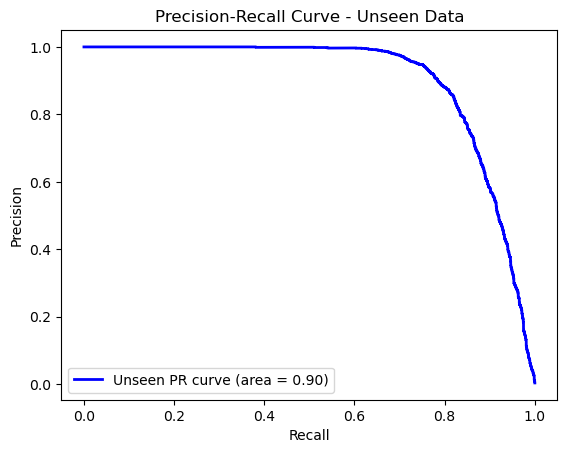

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# ROC Curve for Validation Data
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_pred_proba)
plt.figure()
plt.plot(fpr_val, tpr_val, color='darkorange', lw=2, label='Validation ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Validation Data')
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve for Validation Data
plt.figure()
plt.plot(recall_vals, precision_vals, color='blue', lw=2, label='Validation PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Validation Data')
plt.legend(loc="lower left")
plt.show()

# ROC Curve for Unseen Data
fpr_unseen, tpr_unseen, _ = roc_curve(y_unseen, y_unseen_pred_proba)
plt.figure()
plt.plot(fpr_unseen, tpr_unseen, color='darkorange', lw=2, label='Unseen ROC curve (area = %0.2f)' % roc_auc_unseen)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Unseen Data')
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve for Unseen Data
plt.figure()
plt.plot(recall_vals_unseen, precision_vals_unseen, color='blue', lw=2, label='Unseen PR curve (area = %0.2f)' % pr_auc_unseen)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Unseen Data')
plt.legend(loc="lower left")
plt.show()


Unseen Data Accuracy (Fixed Threshold): 0.9946285802716841
Unseen Data Classification Report (Fixed Threshold):
               precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.41      0.94      0.57      2145

    accuracy                           0.99    555719
   macro avg       0.71      0.97      0.79    555719
weighted avg       1.00      0.99      1.00    555719

Unseen Data Confusion Matrix (Fixed Threshold):
 [[550720   2854]
 [   131   2014]]
Unseen Data ROC AUC Score (Fixed Threshold): 0.9974852790246937
Unseen Data PR AUC Score (Fixed Threshold): 0.8998497943877132


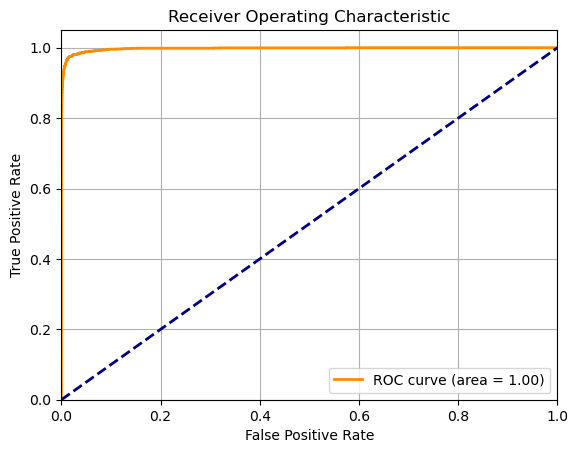

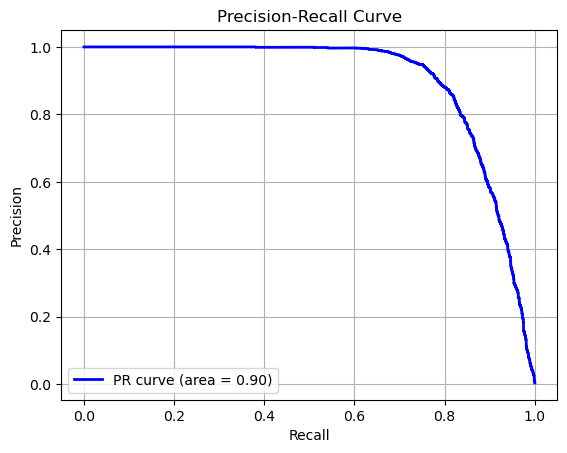

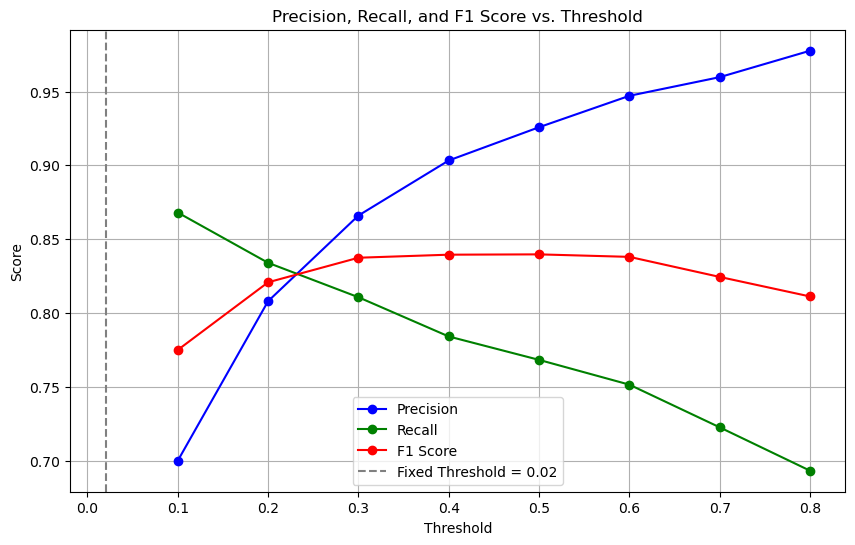

Chosen Fixed Threshold: 0.02


In [39]:
# Import necessary libraries
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Make predictions on the unseen data with the best estimator
y_unseen_pred_proba = xgb_model.predict_proba(X_unseen_rfe)[:, 1]

# Define a fixed threshold (can be manually changed later)
fixed_threshold = 0.02

# Apply the fixed threshold to the predictions
y_unseen_pred_fixed = (y_unseen_pred_proba >= fixed_threshold).astype(int)

# Evaluate the model on the unseen data with the fixed threshold
print("Unseen Data Accuracy (Fixed Threshold):", accuracy_score(y_unseen, y_unseen_pred_fixed))
print("Unseen Data Classification Report (Fixed Threshold):\n", classification_report(y_unseen, y_unseen_pred_fixed))
print("Unseen Data Confusion Matrix (Fixed Threshold):\n", confusion_matrix(y_unseen, y_unseen_pred_fixed))
print("Unseen Data ROC AUC Score (Fixed Threshold):", roc_auc_score(y_unseen, y_unseen_pred_proba))
print("Unseen Data PR AUC Score (Fixed Threshold):", average_precision_score(y_unseen, y_unseen_pred_proba))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_unseen, y_unseen_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Plot Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_unseen, y_unseen_pred_proba)
pr_auc = auc(recall, precision)
plt.figure()
plt.plot(recall, precision, color='b', lw=2, label='PR curve (area = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.grid()
plt.show()

# Varying Thresholds
thresholds = np.arange(0.1, 0.9, 0.1)
precisions = []
recalls = []
f1_scores = []

for threshold in thresholds:
    y_pred = (y_unseen_pred_proba >= threshold).astype(int)
    precisions.append(precision_score(y_unseen, y_pred))
    recalls.append(recall_score(y_unseen, y_pred))
    f1_scores.append(f1_score(y_unseen, y_pred))

# Plot Precision, Recall, F1 Score vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precisions, marker='o', label='Precision', color='blue')
plt.plot(thresholds, recalls, marker='o', label='Recall', color='green')
plt.plot(thresholds, f1_scores, marker='o', label='F1 Score', color='red')
plt.axvline(x=fixed_threshold, color='gray', linestyle='--', label=f'Fixed Threshold = {fixed_threshold}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs. Threshold')
plt.legend()
plt.grid()
plt.show()

# Print the chosen threshold for reference
print("Chosen Fixed Threshold:", fixed_threshold)


   Threshold  Precision    Recall  F1 Score  Accuracy   ROC AUC   PR AUC  \
0       0.02   0.413722  0.938928  0.574362  0.994629  0.997485  0.89985   
1       0.10   0.700000  0.868065  0.775026  0.998055  0.997485  0.89985   
2       0.20   0.808040  0.834033  0.820830  0.998595  0.997485  0.89985   
3       0.30   0.866036  0.810723  0.837467  0.998785  0.997485  0.89985   
4       0.40   0.903330  0.784149  0.839531  0.998843  0.997485  0.89985   
5       0.50   0.925843  0.768298  0.839745  0.998868  0.997485  0.89985   
6       0.60   0.947121  0.751515  0.838056  0.998879  0.997485  0.89985   
7       0.70   0.959752  0.722611  0.824468  0.998812  0.997485  0.89985   
8       0.80   0.977646  0.693240  0.811238  0.998755  0.997485  0.89985   

   True Positives (TP)  False Positives (FP)  True Negatives (TN)  \
0                 2014                  2854               550720   
1                 1862                   798               552776   
2                 1789          

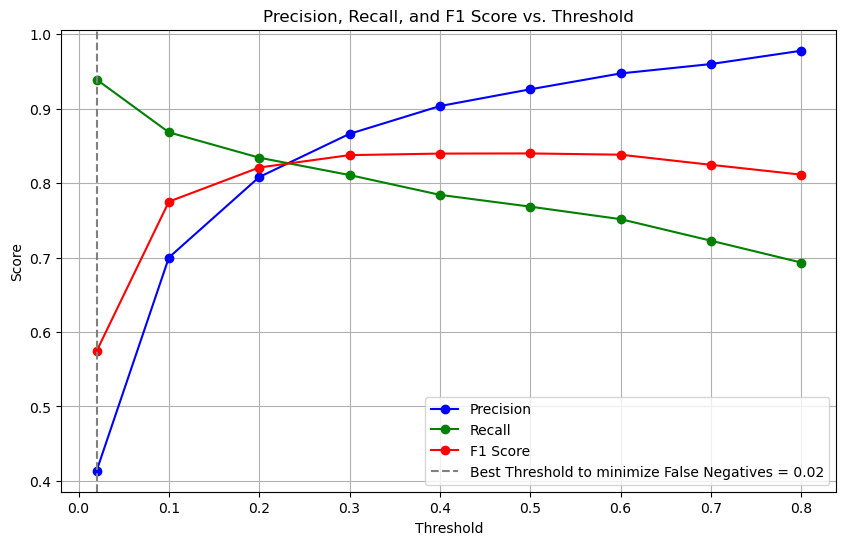

,Threshold,Precision,Recall,F1 Score,Accuracy,ROC AUC,PR AUC,True Positives (TP),False Positives (FP),True Negatives (TN),False Negatives (FN)
0,0.02,0.413722,0.938928,0.574362,0.994629,0.997485,0.89985,2014,2854,550720,131
1,0.10,0.700000,0.868065,0.775026,0.998055,0.997485,0.89985,1862,798,552776,283
2,0.20,0.808040,0.834033,0.820830,0.998595,0.997485,0.89985,1789,425,553149,356
3,0.30,0.866036,0.810723,0.837467,0.998785,0.997485,0.89985,1739,269,553305,406
4,0.40,0.903330,0.784149,0.839531,0.998843,0.997485,0.89985,1682,180,553394,463
5,0.50,0.925843,0.768298,0.839745,0.998868,0.997485,0.89985,1648,132,553442,497
6,0.60,0.947121,0.751515,0.838056,0.998879,0.997485,0.89985,1612,90,553484,533
7,0.70,0.959752,0.722611,0.824468,0.998812,0.997485,0.89985,1550,65,553509,595
8,0.80,0.977646,0.693240,0.811238,0.998755,0.997485,0.89985,1487,34,553540,658


In [45]:
# Import necessary libraries
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, average_precision_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make predictions on the unseen data with the best estimator
y_unseen_pred_proba = xgb_model.predict_proba(X_unseen_rfe)[:, 1]

# Define the range of thresholds including 0.02
thresholds = np.append(np.arange(0.1, 0.9, 0.1), 0.02)
thresholds = np.sort(thresholds)  # Ensure thresholds are sorted

# Initialize lists to store the metrics
metrics_list = []

for threshold in thresholds:
    # Apply the threshold to the predictions
    y_pred = (y_unseen_pred_proba >= threshold).astype(int)
    
    # Calculate the metrics
    precision = precision_score(y_unseen, y_pred)
    recall = recall_score(y_unseen, y_pred)
    f1 = f1_score(y_unseen, y_pred)
    accuracy = accuracy_score(y_unseen, y_pred)
    roc_auc = roc_auc_score(y_unseen, y_unseen_pred_proba)  # This does not change with the threshold
    pr_auc = average_precision_score(y_unseen, y_unseen_pred_proba)  # This does not change with the threshold
    
    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_unseen, y_pred).ravel()
    
    # Append the metrics to the list
    metrics_list.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Accuracy': accuracy,
        'ROC AUC': roc_auc,
        'PR AUC': pr_auc,
        'True Positives (TP)': tp,
        'False Positives (FP)': fp,
        'True Negatives (TN)': tn,
        'False Negatives (FN)': fn
    })

# Convert the metrics list to a DataFrame for better visualization
metrics_df = pd.DataFrame(metrics_list)

# Display the table
print(metrics_df)

# Plot the metrics vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(metrics_df['Threshold'], metrics_df['Precision'], marker='o', label='Precision', color='blue')
plt.plot(metrics_df['Threshold'], metrics_df['Recall'], marker='o', label='Recall', color='green')
plt.plot(metrics_df['Threshold'], metrics_df['F1 Score'], marker='o', label='F1 Score', color='red')
plt.axvline(x=0.02, color='gray', linestyle='--', label='Best Threshold to minimize False Negatives = 0.02')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs. Threshold')
plt.legend()
plt.grid()
plt.show()

# Print the metrics DataFrame
metrics_df


   Threshold  Precision    Recall  F1 Score  Accuracy   ROC AUC   PR AUC  \
0       0.02   0.413722  0.938928  0.574362  0.994629  0.997485  0.89985   
1       0.10   0.700000  0.868065  0.775026  0.998055  0.997485  0.89985   
2       0.20   0.808040  0.834033  0.820830  0.998595  0.997485  0.89985   
3       0.30   0.866036  0.810723  0.837467  0.998785  0.997485  0.89985   
4       0.40   0.903330  0.784149  0.839531  0.998843  0.997485  0.89985   
5       0.50   0.925843  0.768298  0.839745  0.998868  0.997485  0.89985   
6       0.60   0.947121  0.751515  0.838056  0.998879  0.997485  0.89985   
7       0.70   0.959752  0.722611  0.824468  0.998812  0.997485  0.89985   
8       0.80   0.977646  0.693240  0.811238  0.998755  0.997485  0.89985   

   True Positives (TP)  False Positives (FP)  True Negatives (TN)  \
0                 2014                  2854               550720   
1                 1862                   798               552776   
2                 1789          

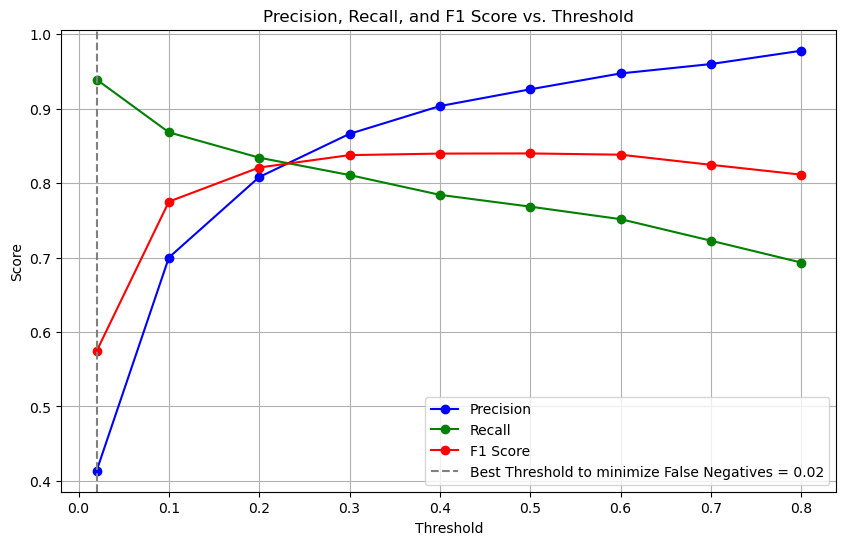

,Threshold,Precision,Recall,F1 Score,Accuracy,ROC AUC,PR AUC,True Positives (TP),False Positives (FP),True Negatives (TN),False Negatives (FN),Total Savings ($),Cost of Operation ($),Net Savings ($)
0,0.02,0.413722,0.938928,0.574362,0.994629,0.997485,0.89985,2014,2854,550720,131,201400,41640,159760
1,0.10,0.700000,0.868065,0.775026,0.998055,0.997485,0.89985,1862,798,552776,283,186200,36280,149920
2,0.20,0.808040,0.834033,0.820830,0.998595,0.997485,0.89985,1789,425,553149,356,178900,39850,139050
3,0.30,0.866036,0.810723,0.837467,0.998785,0.997485,0.89985,1739,269,553305,406,173900,43290,130610
4,0.40,0.903330,0.784149,0.839531,0.998843,0.997485,0.89985,1682,180,553394,463,168200,48100,120100
5,0.50,0.925843,0.768298,0.839745,0.998868,0.997485,0.89985,1648,132,553442,497,164800,51020,113780
6,0.60,0.947121,0.751515,0.838056,0.998879,0.997485,0.89985,1612,90,553484,533,161200,54200,107000
7,0.70,0.959752,0.722611,0.824468,0.998812,0.997485,0.89985,1550,65,553509,595,155000,60150,94850
8,0.80,0.977646,0.693240,0.811238,0.998755,0.997485,0.89985,1487,34,553540,658,148700,66140,82560


In [46]:
# Import necessary libraries
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score, average_precision_score, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Make predictions on the unseen data with the best estimator
y_unseen_pred_proba = xgb_model.predict_proba(X_unseen_rfe)[:, 1]

# Define the range of thresholds including 0.02
thresholds = np.append(np.arange(0.1, 0.9, 0.1), 0.02)
thresholds = np.sort(thresholds)  # Ensure thresholds are sorted

# Initialize lists to store the metrics
metrics_list = []

# Define the costs
fp_cost = 10
fn_cost = 100
tp_savings = 100

for threshold in thresholds:
    # Apply the threshold to the predictions
    y_pred = (y_unseen_pred_proba >= threshold).astype(int)
    
    # Calculate the metrics
    precision = precision_score(y_unseen, y_pred)
    recall = recall_score(y_unseen, y_pred)
    f1 = f1_score(y_unseen, y_pred)
    accuracy = accuracy_score(y_unseen, y_pred)
    roc_auc = roc_auc_score(y_unseen, y_unseen_pred_proba)  # This does not change with the threshold
    pr_auc = average_precision_score(y_unseen, y_unseen_pred_proba)  # This does not change with the threshold
    
    # Confusion matrix values
    tn, fp, fn, tp = confusion_matrix(y_unseen, y_pred).ravel()
    
    # Calculate costs and savings
    total_savings = tp * tp_savings
    cost_of_operation = (fp * fp_cost) + (fn * fn_cost)
    net_savings = total_savings - cost_of_operation
    
    # Append the metrics to the list
    metrics_list.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Accuracy': accuracy,
        'ROC AUC': roc_auc,
        'PR AUC': pr_auc,
        'True Positives (TP)': tp,
        'False Positives (FP)': fp,
        'True Negatives (TN)': tn,
        'False Negatives (FN)': fn,
        'Total Savings ($)': total_savings,
        'Cost of Operation ($)': cost_of_operation,
        'Net Savings ($)': net_savings
    })

# Convert the metrics list to a DataFrame for better visualization
metrics_df = pd.DataFrame(metrics_list)

# Display the table
print(metrics_df)

# Plot the metrics vs. Threshold
plt.figure(figsize=(10, 6))
plt.plot(metrics_df['Threshold'], metrics_df['Precision'], marker='o', label='Precision', color='blue')
plt.plot(metrics_df['Threshold'], metrics_df['Recall'], marker='o', label='Recall', color='green')
plt.plot(metrics_df['Threshold'], metrics_df['F1 Score'], marker='o', label='F1 Score', color='red')
plt.axvline(x=0.02, color='gray', linestyle='--', label='Best Threshold to minimize False Negatives = 0.02')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 Score vs. Threshold')
plt.legend()
plt.grid()
plt.show()

# Print the metrics DataFrame
metrics_df

## Assumptions:

- **False Positive Cost (`fp_cost`):** \$10
- **False Negative Cost (`fn_cost`):** \$100
- **True Positive Savings (`tp_savings`):** \$100

## Recommendation:

### If Minimizing False Negatives (FN) is Critical:
**Threshold = 0.02** would be the best choice as it catches most fraudulent transactions (Recall = 0.938928), but it has a lower precision (0.413722) and higher operational cost due to a larger number of false positives (2854). The net savings at this threshold are \$159,760.

### If a Balanced Approach is Preferred:
**Threshold = 0.30** offers a strong balance between recall (0.810723) and precision (0.866036), leading to fewer false positives (269) and a reasonable number of false negatives (406). This threshold provides net savings of \$130,610. However, it’s worth noting that **Threshold = 0.20** achieves slightly higher net savings (\$139,050) with a good balance between recall (0.834033) and precision (0.808040).

### If Minimizing False Positives (FP) is Critical:
**Threshold = 0.50** or **Threshold = 0.60** could be preferred, offering high precision (0.925843 and 0.947121, respectively) and minimizing the number of legitimate transactions flagged as fraudulent. However, these thresholds result in lower net savings of \$113,780 and \$107,000 respectively compared to more balanced thresholds.

## Conclusion:
**Threshold = 0.02** is recommended if the priority is to minimize false negatives and maximize fraud detection, resulting in the highest net savings (\$159,760). If a more balanced approach is preferred, **Threshold = 0.20** provides the best trade-off between saving money for stakeholders and maintaining good detection performance, with net savings of \$139,050.


In [47]:
'''
import joblib

# Save the processed training dataset
joblib.dump((X_train_rfe, y_train), 'X_train_rfe_y_train.joblib')

# Save the processed validation dataset
joblib.dump((X_val_rfe, y_val), 'X_val_rfe_y_val.joblib')

# Save the processed unseen dataset
joblib.dump((X_unseen_rfe, y_unseen), 'X_unseen_rfe_y_unseen.joblib')

# Save the trained XGBoost model
joblib.dump(xgb_model, 'final_model.joblib')

'''

"\nimport joblib\n\n# Save the processed training dataset\njoblib.dump((X_train_rfe, y_train), 'X_train_rfe_y_train.joblib')\n\n# Save the processed validation dataset\njoblib.dump((X_val_rfe, y_val), 'X_val_rfe_y_val.joblib')\n\n# Save the processed unseen dataset\njoblib.dump((X_unseen_rfe, y_unseen), 'X_unseen_rfe_y_unseen.joblib')\n\n# Save the trained XGBoost model\njoblib.dump(xgb_model, 'final_model.joblib')\n\n"

In [48]:
'''
# Load the training dataset
X_train_rfe, y_train = joblib.load('X_train_rfe_y_train.joblib')

# Load the validation dataset
X_val_rfe, y_val = joblib.load('X_val_rfe_y_val.joblib')

# Load the unseen dataset
X_unseen_rfe, y_unseen = joblib.load('X_unseen_rfe_y_unseen.joblib')

# Load the trained XGBoost model
xgb_model = joblib.load('final_model.joblib')
'''

"\n# Load the training dataset\nX_train_rfe, y_train = joblib.load('X_train_rfe_y_train.joblib')\n\n# Load the validation dataset\nX_val_rfe, y_val = joblib.load('X_val_rfe_y_val.joblib')\n\n# Load the unseen dataset\nX_unseen_rfe, y_unseen = joblib.load('X_unseen_rfe_y_unseen.joblib')\n\n# Load the trained XGBoost model\nxgb_model = joblib.load('final_model.joblib')\n"

In [21]:
X_train.columns

Index(['cc_num', 'merchant', 'category', 'amt', 'gender', 'city', 'state',
       'city_pop', 'job', 'trans_hour', 'trans_month', 'trans_dayofweek',
       'timedelta_last_trans', 'cust_age'],
      dtype='object')

In [22]:
categorical_cols = ['merchant', 'category', 'gender', 'city', 'state', 'job', 'trans_dayofweek']
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)


In [23]:
original_numeric_features = ['cc_num', 'amt', 'city_pop', 'trans_hour', 'trans_month', 'timedelta_last_trans', 'cust_age']
final_feature_names = list(original_numeric_features) + list(ohe_feature_names)


In [24]:
selected_feature_indices = rfe.get_support(indices=True)
selected_feature_names = [final_feature_names[i] for i in selected_feature_indices]


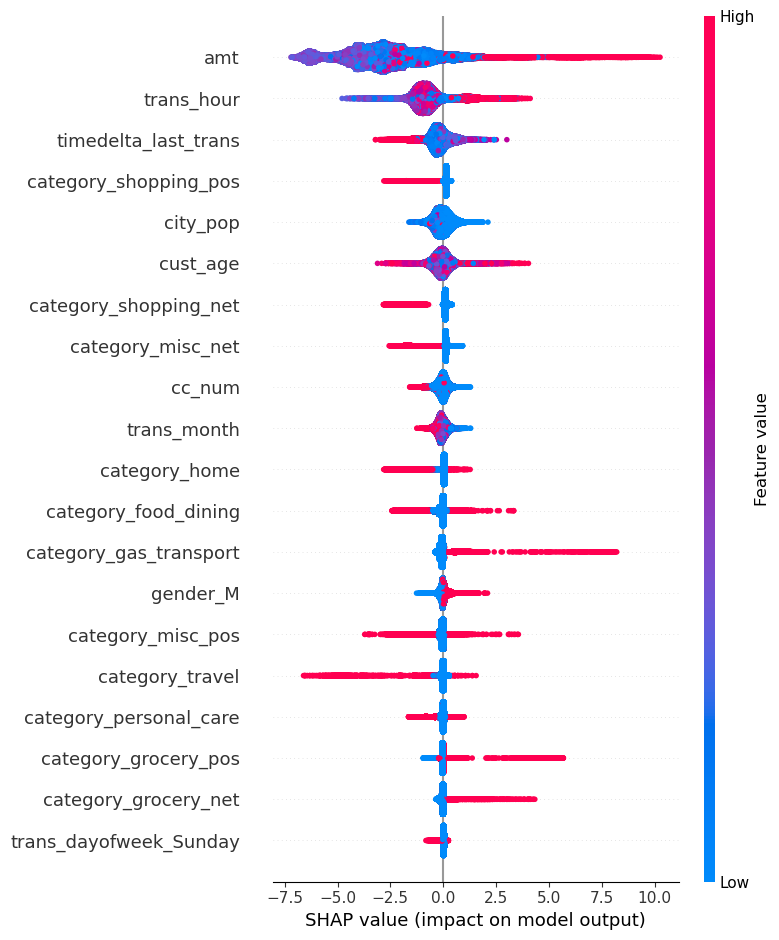

In [25]:
import shap

# Assuming `shap_values` and `explainer` are already computed
shap.summary_plot(shap_values, features=X_val_rfe.toarray(), feature_names=selected_feature_names)


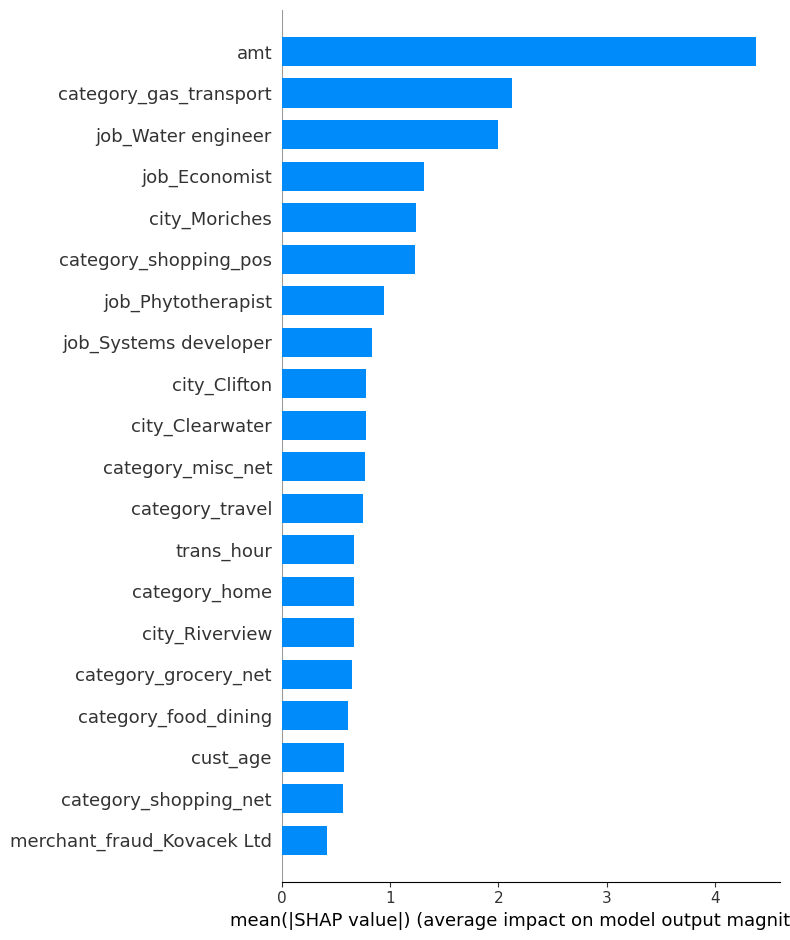

<Figure size 1000x800 with 0 Axes>

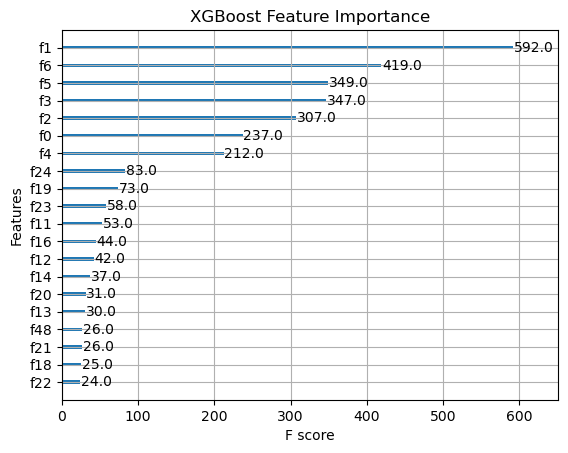

In [26]:
import shap
import numpy as np
from xgboost import plot_importance
import matplotlib.pyplot as plt

# Assuming `X_val_rfe` is a sparse matrix, convert it to dense
X_val_rfe_dense = X_val_rfe.toarray()

# Initialize the SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for the validation data
shap_values = explainer.shap_values(X_val_rfe_dense)

# Assuming `selected_feature_names` is a list of the RFE-selected feature names
# Summary plot of SHAP values
shap.summary_plot(shap_values, X_val_rfe_dense, feature_names=selected_feature_names, plot_type="bar")

# Feature importance plot using XGBoost's plot_importance function
plt.figure(figsize=(10, 8))
plot_importance(xgb_model, max_num_features=20, importance_type='weight', title='XGBoost Feature Importance')
plt.title("XGBoost Feature Importance")
plt.show()
